In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [2]:
# my file
file1 = "/home/zhe2/data/PACE/xSec_fit_output/interim_20250927T123954_retrieval_full_parallel.nc"
# read the data
ds = xr.open_dataset(file1)
# loc
lat = ds['latitude'].values
lon = ds['longitude'].values
# sif coeff.
sif_ev1 = ds['sif_ev1'].values
# state variables
x_hat = ds['x_hat'].values
# reconstructed SIF at 687.2
sif_recon = ds['sif_radiance_678nm'].values

In [3]:
ds

<xarray.Dataset> Size: 215MB
Dimensions:             (scans: 1710, pixels: 1272, state: 15, sif_nev: 1)
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables: (12/16)
    latitude            (scans, pixels) float32 9MB 53.2 53.24 ... 77.6 77.59
    longitude           (scans, pixels) float32 9MB -28.57 -28.48 ... 23.89
    x_hat               (state, scans, pixels) float32 131MB nan nan ... nan nan
    converged           (scans, pixels) uint8 2MB ...
    status_code         (scans, pixels) int16 4MB ...
    n_steps             (scans, pixels) int16 4MB ...
    ...                  ...
    sif_coeffs          (sif_nev, scans, pixels) float32 9MB ...
    sif_radiance_678nm  (scans, pixels) float32 9MB nan nan nan ... nan nan nan
    is_dark             (scans, pixels) uint8 2MB ...
    is_ocean            (scans, pixels) uint8 2MB ...
    source_pixel_index  (pixels) int32 5kB ...
    source_scan_index   (scans) int32 7kB ...
Attributes:
    title:            PACE toy retrieval swath output (full NC)
    history:          Created 2026-03-11T11:44:51
    input_pace_file:  /home/zhe2/data/PACE/xSec_fit_interim/interim_20250927T...
    config_file:      /home/zhe2/data/PACE/xSec_fit_interim/tmp_config_202509...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      1
    pixel_end:        1272
    scan_start:       1
    scan_end:         1710

In [4]:
# stats of converged
converged = ds['converged'].values
# 1-converged, 0-not converged
converged_1 = np.nansum(converged)
# total number of pixels
total_pixels = np.prod(converged.shape)
# valid pixels
valid_pixels = np.sum(~np.isnan(sif_recon))
# percentage of valid pixels
valid_percentage = valid_pixels/total_pixels
# percentage of converged
converged_percentage = converged_1/valid_pixels

print("Percentage of valid pixels: ", valid_percentage)
print("Percentage of converged pixels: ", converged_percentage)



Percentage of valid pixels:  0.163766137040715
Percentage of converged pixels:  0.31458601783774226


In [5]:
dirr = "/home/zhe2/data/MyProjects/PACE_redSIF_PACE/Files_in_use/"
ds_pace = dirr + "sample_granule_20240830T131442_new_chl.nc"
ds_pace = xr.open_dataset(ds_pace)
# pace file vars
lat_pace = ds_pace['latitude'].values
lon_pace = ds_pace['longitude'].values
chl_pace = ds_pace['chlor_a'].values
nflh_pace = ds_pace['nflh'].values


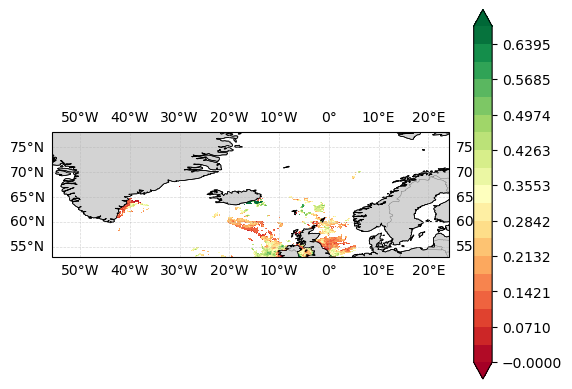

In [6]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon) - buffer_bnd
lon_max = np.max(lon) + buffer_bnd
lat_min = np.min(lat) - buffer_bnd
lat_max = np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(np.nanpercentile(nflh_pace, .5), np.nanpercentile(nflh_pace, 99.5), 20)
im = ax.contourf(lon_pace, lat_pace, nflh_pace, 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [7]:
sif_recon_masked = np.where(converged == 1, sif_recon, np.nan)

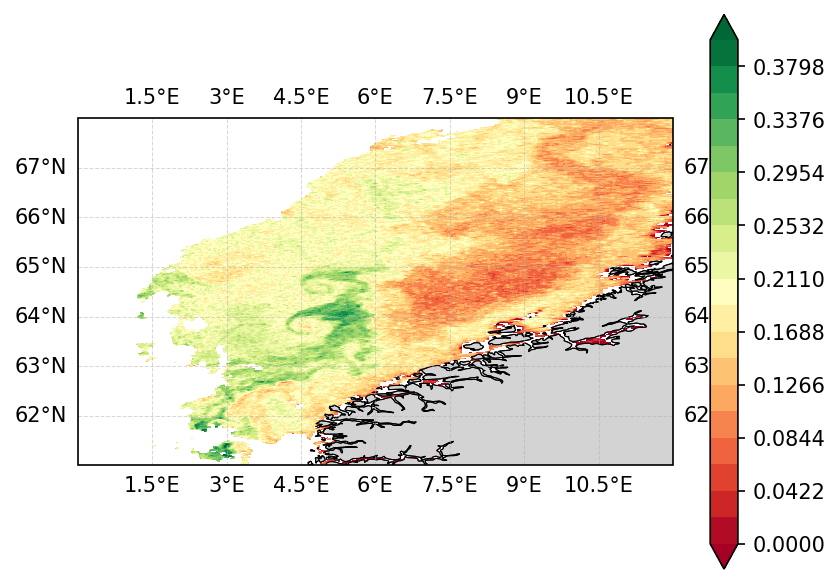

In [8]:
# mapping
fig = plt.figure(dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = 0   # np.min(lon) - buffer_bnd
lon_max = 12  # np.max(lon) + buffer_bnd
lat_min = 61  # np.min(lat) - buffer_bnd
lat_max = 68  # np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
ax.set_extent(extend, crs=ccrs.PlateCarree())  # Global

# Plot nFLH data using contourf
levels = np.linspace(0, 0.4009, 20)# np.linspace(np.nanpercentile(sif_recon, .5), np.nanpercentile(sif_recon, 99.5), 20)
im = ax.contourf(lon, lat, sif_recon, 
                 levels=levels,
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 extend='both')
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

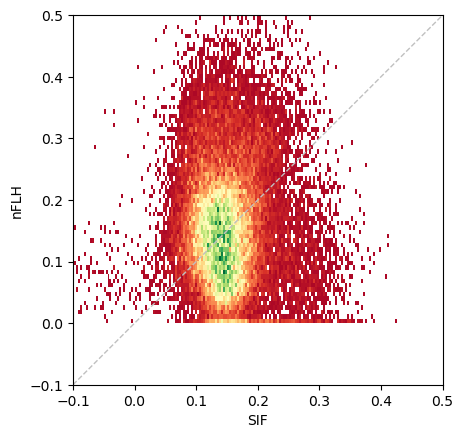

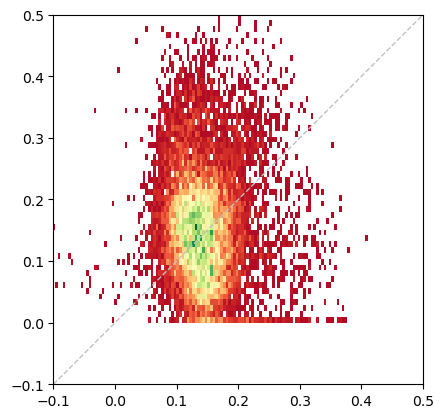

In [9]:
# density kernel plot of nflh vs. sif_recon
fig, ax = plt.subplots()
sns.histplot(x = sif_recon.flatten(), y = nflh_pace.flatten(), ax=ax, cmap='RdYlGn', fill=True)
ax.set_xlim(-.1, .5)
ax.set_ylim(-.1, .5)
ax.set_aspect('equal')
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='silver', ls='--', linewidth=1)
ax.set_xlabel('SIF')
ax.set_ylabel('nFLH')
plt.show()

# another figure showing only the converged pixels
fig, ax = plt.subplots()
sns.histplot(x = sif_recon[converged == 1].flatten(), y = nflh_pace[converged == 1].flatten(), ax=ax, cmap='RdYlGn', fill=True)
ax.set_xlim(-.1, .5)
ax.set_ylim(-.1, .5)
ax.set_aspect('equal')
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='silver', ls='--', linewidth=1)

In [31]:
# load L2 AOP and BGC data - nflh and chlor_a
granule_id = '20250927T123954'
dir_aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/"
dir_bgc = "/home/zhe2/data/PACE/L2_BGC_V3.1/"
file_aop = dir_aop + "PACE_OCI." + granule_id + ".L2.OC_AOP.V3_1.nc"
file_bgc = dir_bgc + "PACE_OCI." + granule_id + ".L2.OC_BGC.V3_1.nc"
dtr_aop = xr.open_datatree(file_aop)
ds_aop = xr.merge(dtr_aop.to_dict().values())
dtr_bgc = xr.open_datatree(file_bgc)
ds_bgc = xr.merge(dtr_bgc.to_dict().values())
# chlor_a
chlor_a = ds_bgc['chlor_a'].values
# nflh
nflh = ds_aop['nflh'].values
# phytoplankton carbon
phyto_c = ds_bgc['carbon_phyto'].values
# poc
poc = ds_bgc['poc'].values

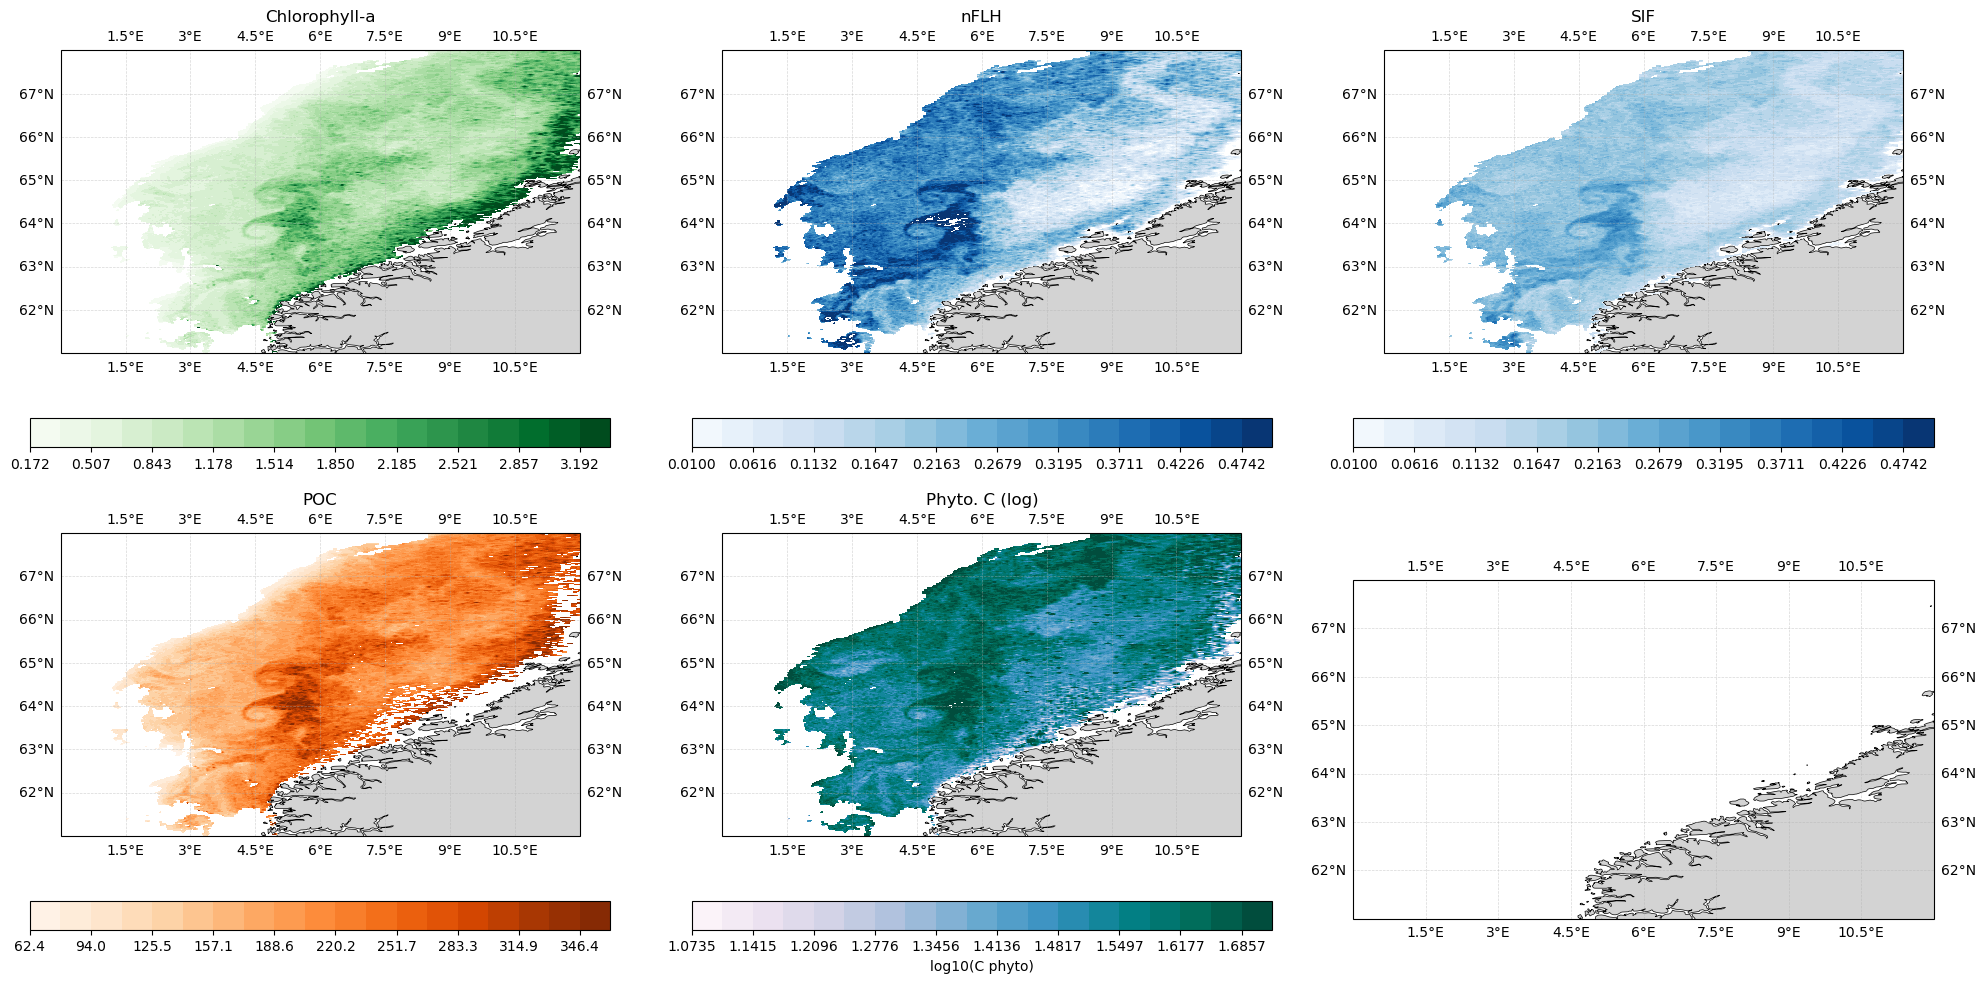

In [89]:
# 1x5 plot of chlor_a, nflh, sif_recon, poc, and c_phyto using lat/lon from ds
fig, axes = plt.subplots(2, 3, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axes.flatten()
axs[0].set_title('Chlorophyll-a')
axs[1].set_title('nFLH')
axs[2].set_title('SIF')
axs[3].set_title('POC')
axs[4].set_title('Phyto. C (log)')

# Compute percentiles/ranges and levels for colorbars
chlor_a_range = np.nanpercentile(chlor_a, [0.5, 99.5])
nflh_range = np.nanpercentile(nflh, [0.5, 99.5])
sif_recon_range = np.nanpercentile(sif_recon, [0.5, 99.5])
poc_range = np.nanpercentile(poc, [0.5, 99.5])
phyto_c_range = np.nanpercentile(phyto_c[phyto_c > 0], [5, 95])  # avoid log(0)

levels_chlor_a = np.linspace(chlor_a_range[0], round(chlor_a_range[1], 2), 20)
levels_fluor = np.linspace(0.01, 0.5, 20) # np.linspace(max(nflh_range[0], sif_recon_range[0]),round( min(nflh_range[1], sif_recon_range[1]), 1), 20)
levels_poc = np.linspace(poc_range[0], poc_range[1], 20)
levels_phyto_c = np.linspace(np.log10(phyto_c_range[0]), np.log10(phyto_c_range[1]), 20)

# Set map extent
lon_min, lon_max = 0, 12
lat_min, lat_max = 61, 68
extend = [lon_min, lon_max, lat_min, lat_max]

# Plot maps
im1 = axs[0].contourf(lon, lat, chlor_a, cmap='Greens', transform=ccrs.PlateCarree(), levels=levels_chlor_a)
im2 = axs[1].contourf(lon, lat, nflh, cmap='Blues', transform=ccrs.PlateCarree(), levels=levels_fluor)
im3 = axs[2].contourf(lon, lat, sif_recon, cmap='Blues', transform=ccrs.PlateCarree(), levels=levels_fluor)
im4 = axs[3].contourf(lon, lat, poc, cmap='Oranges', transform=ccrs.PlateCarree(), levels=levels_poc)
# For phyto_c, mask nonpositive for log; avoid warnings
with np.errstate(divide='ignore', invalid='ignore'):
    log_phyto_c = np.full_like(phyto_c, np.nan)
    positive_mask = phyto_c > 0
    log_phyto_c[positive_mask] = np.log10(phyto_c[positive_mask])
im5 = axs[4].contourf(lon, lat, log_phyto_c, cmap='PuBuGn', transform=ccrs.PlateCarree(), levels=levels_phyto_c)

cbar1 = plt.colorbar(im1, ax=axs[0], orientation='horizontal')
cbar2 = plt.colorbar(im2, ax=axs[1], orientation='horizontal')
cbar3 = plt.colorbar(im3, ax=axs[2], orientation='horizontal')
cbar4 = plt.colorbar(im4, ax=axs[3], orientation='horizontal')
cbar5 = plt.colorbar(im5, ax=axs[4], orientation='horizontal')
cbar5.set_label('log10(C phyto)')

# Set extent and coastlines, gridlines, features
for ax in axs:
    ax.set_extent(extend, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)

plt.tight_layout()
plt.show()


In [84]:
# compare a transect of chlor_a, nflh, and sif_recon
# choose a transect line where np.where
lon_transect_min = 3
lon_transect_max = 7.5
lat_transect_min = 63
lat_transect_max = 65.5
# get the indices of the transect
transect_indices = np.where((lon >= lon_transect_min) & (lon <= lon_transect_max) & (lat >= lat_transect_min) & (lat <= lat_transect_max))
# get the values of chlor_a, nflh, and sif_recon along the transect
chlor_a_transect = chlor_a[transect_indices]
nflh_transect = nflh[transect_indices]
sif_recon_transect = sif_recon[transect_indices]
poc_transect = poc[transect_indices]
phyto_c_transect = phyto_c[transect_indices]
lon_transect = lon[transect_indices]
lat_transect = lat[transect_indices]


(-3.0, 3.0)

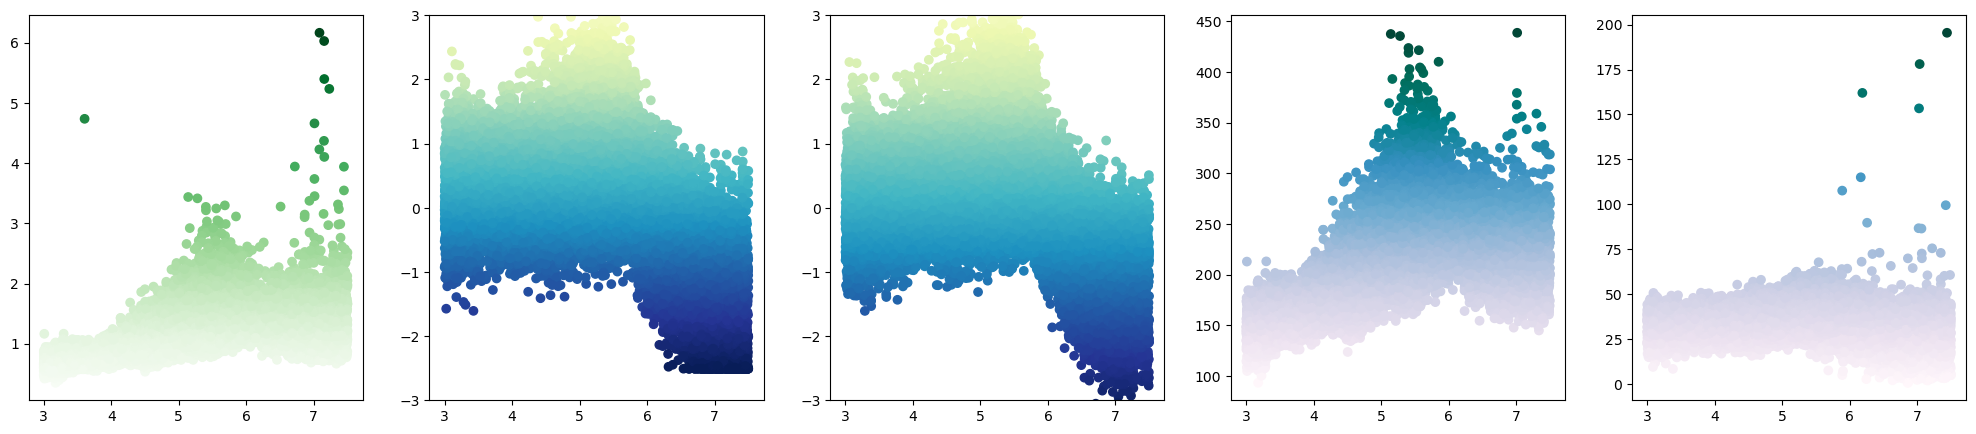

In [85]:
# scatter plot of chlor_a, nflh, sif_recon, and phyto_c vs. lon => make it a 1x4 plot
# normalize nflh using sd and mean
nflh_transect_norm = (nflh_transect - np.nanmean(nflh_transect)) / np.nanstd(nflh_transect)
sif_recon_transect_norm = (sif_recon_transect - np.nanmean(sif_recon_transect)) / np.nanstd(sif_recon_transect)
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
axs[0].scatter(lon_transect, chlor_a_transect, c=chlor_a_transect, cmap='Greens')
axs[1].scatter(lon_transect, nflh_transect_norm, c=nflh_transect_norm, cmap='YlGnBu_r')
axs[2].scatter(lon_transect, sif_recon_transect_norm, c=sif_recon_transect_norm, cmap='YlGnBu_r')
axs[3].scatter(lon_transect, poc_transect, c=poc_transect, cmap='PuBuGn')
axs[4].scatter(lon_transect, phyto_c_transect, c=phyto_c_transect, cmap='PuBuGn')

# ylim
axs[1].set_ylim(-3, 3)
axs[2].set_ylim(-3, 3)


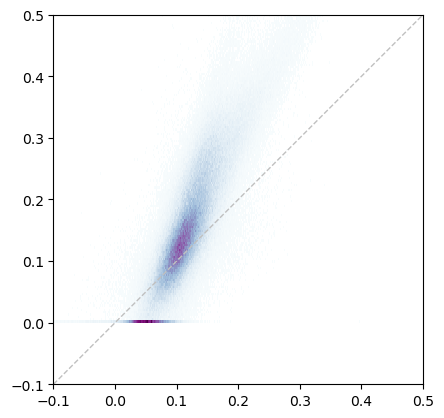

In [12]:
# nflh vs. sif_recon
fig, ax = plt.subplots()
sns.histplot(x = sif_recon.flatten(), y = nflh.flatten(), ax=ax, cmap='BuPu', fill=True)
ax.set_xlim(-.1, .5)
ax.set_ylim(-.1, .5)
ax.set_aspect('equal')
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='silver', ls='--', linewidth=1)

KeyboardInterrupt: 

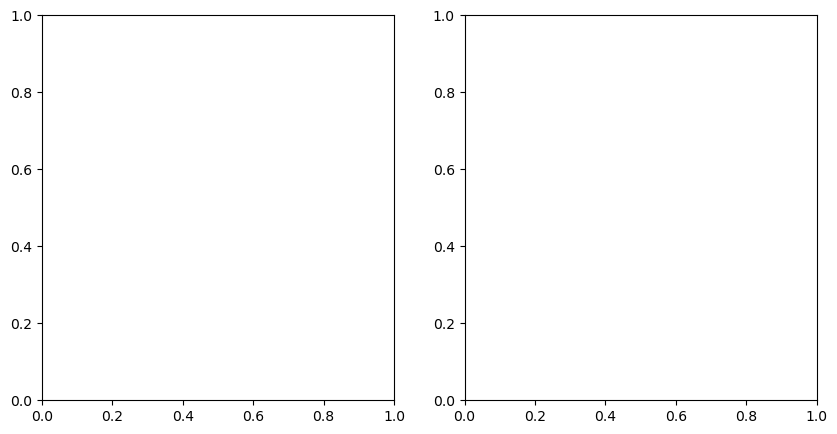

In [13]:
# 1x2 subplots of chlor_a vs. nflh and chlor_a vs. sif_recon
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# sns.histplot(x = chlor_a.flatten(), y = nflh.flatten(), ax=axs[0], cmap='BuPu')
# axs[0].set_xlim(0, 1)
# axs[0].set_ylim(0, .5)
sns.histplot(x = chlor_a.flatten(), y = sif_recon.flatten(), ax=axs[1], cmap='BuPu')
axs[1].set_xlim(0, 1)
axs[1].set_ylim(0, .5)
plt.show()
